In [1]:
import subprocess
subprocess.run(['pip', 'install', 'tensorflow', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn'], check=True)

print("✅ All packages ready!")

✅ All packages ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow version: {tf.__version__}")
print("✅ All imports successful!")

✅ TensorFlow version: 2.20.0
✅ All imports successful!


In [3]:
train_df = pd.read_csv('../dataset/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('../dataset/UNSW_NB15_testing-set.csv')

In [4]:
print("=== Training Label Distribution ===")
print(train_df['label'].value_counts())
print(f"  0 = Normal  |  1 = Attack")

print("\n=== Attack Categories in Training ===")
print(train_df['attack_cat'].value_counts())

=== Training Label Distribution ===
label
1    45332
0    37000
Name: count, dtype: int64
  0 = Normal  |  1 = Attack

=== Attack Categories in Training ===
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [5]:

DROP_COLS = ['id', 'attack_cat']

CAT_COLS = ['proto', 'service', 'state']

def preprocess(df, encoders=None, fit=True):
    df = df.drop(columns=DROP_COLS, errors='ignore').copy()
    
    
    y = df['label'].values
    df = df.drop(columns=['label'])
    
    
    if encoders is None:
        encoders = {}
    
    for col in CAT_COLS:
        if col in df.columns:
            if fit:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encoders[col] = le
            else:
                le = encoders[col]
                
                df[col] = df[col].astype(str).apply(
                    lambda x: le.transform([x])[0] if x in le.classes_ else 0
                )
    
    return df.values, y, encoders



X_train_raw, y_train, encoders = preprocess(train_df, fit=True)


X_test_raw, y_test, _ = preprocess(test_df, encoders=encoders, fit=False)

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test  shape: {X_test_raw.shape}")
print("✅ Preprocessing done!")

X_train shape: (82332, 42)
X_test  shape: (175341, 42)
✅ Preprocessing done!


In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

X_train = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

n_features = X_train.shape[2]
print(f"Final shapes  →  Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Number of features: {n_features}")
print("✅ Scaling & reshaping done!")

Final shapes  →  Train: (82332, 1, 42)  |  Test: (175341, 1, 42)
Number of features: 42
✅ Scaling & reshaping done!


In [7]:

model = Sequential([
    Input(shape=(1, n_features)),
    LSTM(128, return_sequences=True),   
    Dropout(0.3),                       
    LSTM(64, return_sequences=False),   
    Dropout(0.3),
    Dense(32, activation='relu'),      
    Dense(1, activation='sigmoid')      
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        87,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,073 (543.25 KB)

 Trainable params: 139,073 (543.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("🚀 Training started...")

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,     
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

🚀 Training started...
Epoch 1/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8281 - loss: 0.3578 - val_accuracy: 0.6590 - val_loss: 0.6752
Epoch 2/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9073 - loss: 0.1859 - val_accuracy: 0.8149 - val_loss: 0.4729
Epoch 3/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9221 - loss: 0.1636 - val_accuracy: 0.7384 - val_loss: 0.5554
Epoch 4/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9335 - loss: 0.1460 - val_accuracy: 0.8722 - val_loss: 0.3551
Epoch 5/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9392 - loss: 0.1366 - val_accuracy: 0.8601 - val_loss: 0.3404
Epoch 6/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9441 - loss: 0.1280 - val_accuracy: 0.8167 - val_loss: 0.4087
Epoch 7/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9467 - loss: 0.1232 - val_accuracy: 0.8494 - val_loss: 0.3852
Epoch 8/20
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9477 - loss: 0.

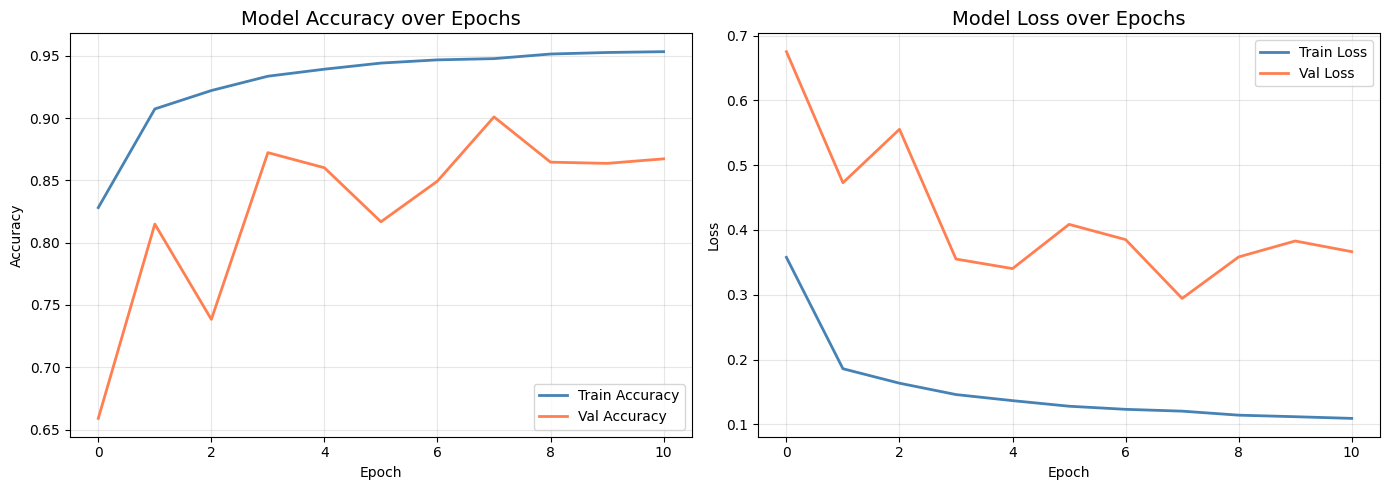

📊 Training history saved as training_history.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral',    linewidth=2)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='coral',    linewidth=2)
axes[1].set_title('Model Loss over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Training history saved as training_history.png")

In [10]:

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
print(f"{'='*45}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"{'='*45}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)']))

  Test Accuracy : 88.48%

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.75      0.97      0.84     56000
  Attack (1)       0.98      0.85      0.91    119341

    accuracy                           0.88    175341
   macro avg       0.86      0.91      0.88    175341
weighted avg       0.91      0.88      0.89    175341



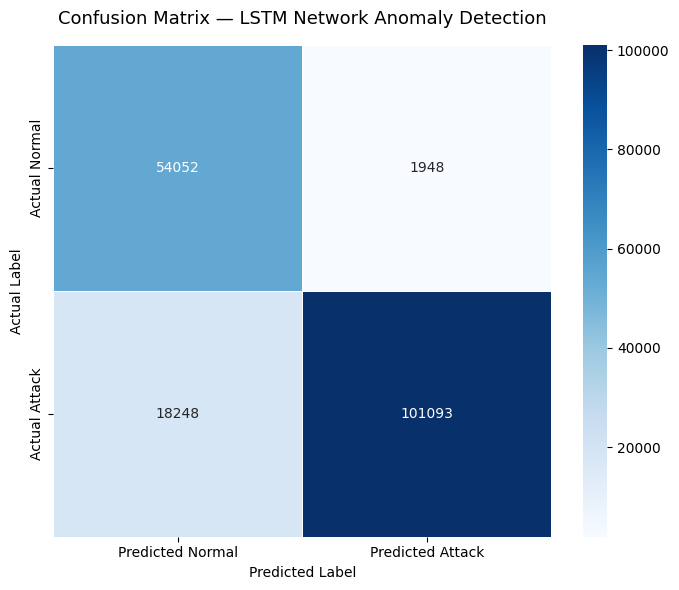


True  Negatives (Normal correctly identified): 54,052
False Positives (Normal flagged as Attack)   : 1,948
False Negatives (Attack missed)              : 18,248
True  Positives (Attack correctly detected)  : 101,093

📊 Confusion matrix saved as confusion_matrix.png


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Attack'],
    yticklabels=['Actual Normal', 'Actual Attack'],
    linewidths=0.5
)
plt.title('Confusion Matrix — LSTM Network Anomaly Detection', fontsize=13, pad=15)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (Normal correctly identified): {tn:,}")
print(f"False Positives (Normal flagged as Attack)   : {fp:,}")
print(f"False Negatives (Attack missed)              : {fn:,}")
print(f"True  Positives (Attack correctly detected)  : {tp:,}")
print("\n📊 Confusion matrix saved as confusion_matrix.png")

In [12]:
model.save('lstm .keras')
print("✅ Model saved as 'lstm_anomaly_model.keras'")
print("\nYou can reload it anytime with:")
print("  from tensorflow.keras.models import load_model")
print("  model = load_model('lstm_anomaly_model.keras')")

✅ Model saved as 'lstm_anomaly_model.keras'

You can reload it anytime with:
  from tensorflow.keras.models import load_model
  model = load_model('lstm_anomaly_model.keras')
